<a href="https://colab.research.google.com/github/ryouchinsa/Rectlabel-support/blob/master/notebooks/train_rf_detr_instance_segmentation_on_custom_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# How to Train a RF-DETR Instance Segmentation Model with Custom Data

We will show you how to train a RF-DETR instance segmentation model with your images and annotations and export to a Core ML model which can be used for auto labeling on RectLabel.

### Use GPU

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Runtime` -> `Change runtime type` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [ ]:
!nvidia-smi

Sun Mar 29 15:06:47 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Install PyTorch 2.8.0

In [ ]:
!pip install -q torch==2.8.0 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 MB 79.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 889.0/889.0 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 75.5 MB/s eta 0:00:00


### Install RF-DETR 1.5.1

In [ ]:
!pip install -q rfdetr==1.5.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.9/187.9 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.9/274.9 kB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 107.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.4/217.4 kB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 96.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 140.5 MB/s eta 0:00:00


### Download training images and annotations

Download training images and annotations. You can use these or replace them with your own data.

In [ ]:
!mkdir datasets
%cd datasets
!wget -q https://huggingface.co/datasets/rectlabel/datasets/resolve/main/donut_coco.zip
!unzip -q donut_coco.zip
%cd ..

/content/datasets
/content


### Fine-tune RF-DETR on custom dataset

Start training from the current content folder.

In [ ]:
from rfdetr import RFDETRSegNano

model = RFDETRSegNano()
dataset_dir = "datasets/donut_coco"
model.train(dataset_dir=dataset_dir, epochs=10, batch_size=4, grad_accum_steps=4)

[2026-03-29 14:56:58] [INFO] rf-detr - Downloading pretrained weights for rf-detr-seg-nano.pt


rf-detr-seg-nano.pt:   0%|          | 0.00/128M [00:00<?, ?iB/s]

[2026-03-29 14:57:00] [INFO] rf-detr - MD5 validation successful for rf-detr-seg-nano.pt


[2026-03-29 14:57:00] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-03-29 14:57:00] [WARNING] rf-detr - Using patch size 12 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-03-29 14:57:00] [INFO] rf-detr - Loading pretrain weights


...

[2026-03-29 14:59:31] [INFO] rf-detr - Epoch: [6/10]  [0/5]  eta: 0:00:36  lr: 0.000100  class_error: 0.00  loss: 22.5044 (22.5044)  loss_ce: 2.4456 (2.4456)  loss_bbox: 0.1668 (0.1668)  loss_giou: 0.1921 (0.1921)  loss_mask_ce: 0.1202 (0.1202)  loss_mask_dice: 0.1338 (0.1338)  loss_ce_0: 5.0866 (5.0866)  loss_bbox_0: 0.0846 (0.0846)  loss_giou_0: 0.1059 (0.1059)  loss_mask_ce_0: 0.1173 (0.1173)  loss_mask_dice_0: 0.1543 (0.1543)  loss_ce_1: 3.2199 (3.2199)  loss_bbox_1: 0.0954 (0.0954)  loss_giou_1: 0.1144 (0.1144)  loss_mask_ce_1: 0.1237 (0.1237)  loss_mask_dice_1: 0.1471 (0.1471)  loss_ce_2: 2.9214 (2.9214)  loss_bbox_2: 0.1370 (0.1370)  loss_giou_2: 0.1550 (0.1550)  loss_mask_ce_2: 0.1124 (0.1124)  loss_mask_dice_2: 0.1655 (0.1655)  loss_ce_enc: 5.8056 (5.8056)  loss_bbox_enc: 0.2307 (0.2307)  loss_giou_enc: 0.2436 (0.2436)  loss_mask_ce_enc: 0.1815 (0.1815)  loss_mask_dice_enc: 0.2440 (0.2440)  loss_ce_unscaled: 0.4891 (0.4891)  class_error_unscaled: 0.0000 (0.0000)  loss_bbox_uns

[2026-03-29 15:00:03] [INFO] rf-detr - Epoch: [7/10]  [0/5]  eta: 0:00:41  lr: 0.000100  class_error: 0.00  loss: 20.5155 (20.5155)  loss_ce: 1.9536 (1.9536)  loss_bbox: 0.1343 (0.1343)  loss_giou: 0.1797 (0.1797)  loss_mask_ce: 0.1185 (0.1185)  loss_mask_dice: 0.1541 (0.1541)  loss_ce_0: 4.7478 (4.7478)  loss_bbox_0: 0.0983 (0.0983)  loss_giou_0: 0.1337 (0.1337)  loss_mask_ce_0: 0.1088 (0.1088)  loss_mask_dice_0: 0.1875 (0.1875)  loss_ce_1: 2.8783 (2.8783)  loss_bbox_1: 0.0998 (0.0998)  loss_giou_1: 0.1355 (0.1355)  loss_mask_ce_1: 0.1144 (0.1144)  loss_mask_dice_1: 0.1688 (0.1688)  loss_ce_2: 2.3510 (2.3510)  loss_bbox_2: 0.1033 (0.1033)  loss_giou_2: 0.1439 (0.1439)  loss_mask_ce_2: 0.1336 (0.1336)  loss_mask_dice_2: 0.1683 (0.1683)  loss_ce_enc: 5.0740 (5.0740)  loss_bbox_enc: 0.4723 (0.4723)  loss_giou_enc: 0.4106 (0.4106)  loss_mask_ce_enc: 0.1507 (0.1507)  loss_mask_dice_enc: 0.2948 (0.2948)  loss_ce_unscaled: 0.3907 (0.3907)  class_error_unscaled: 0.0000 (0.0000)  loss_bbox_uns

[2026-03-29 15:00:27] [INFO] rf-detr - Epoch: [8/10]  [0/5]  eta: 0:00:35  lr: 0.000100  class_error: 0.00  loss: 18.6581 (18.6581)  loss_ce: 1.6615 (1.6615)  loss_bbox: 0.1350 (0.1350)  loss_giou: 0.1793 (0.1793)  loss_mask_ce: 0.1257 (0.1257)  loss_mask_dice: 0.1398 (0.1398)  loss_ce_0: 4.2794 (4.2794)  loss_bbox_0: 0.1120 (0.1120)  loss_giou_0: 0.1407 (0.1407)  loss_mask_ce_0: 0.1228 (0.1228)  loss_mask_dice_0: 0.1687 (0.1687)  loss_ce_1: 2.6952 (2.6952)  loss_bbox_1: 0.1003 (0.1003)  loss_giou_1: 0.1297 (0.1297)  loss_mask_ce_1: 0.1212 (0.1212)  loss_mask_dice_1: 0.1469 (0.1469)  loss_ce_2: 1.9334 (1.9334)  loss_bbox_2: 0.1231 (0.1231)  loss_giou_2: 0.1556 (0.1556)  loss_mask_ce_2: 0.1210 (0.1210)  loss_mask_dice_2: 0.1440 (0.1440)  loss_ce_enc: 4.6460 (4.6460)  loss_bbox_enc: 0.4088 (0.4088)  loss_giou_enc: 0.4502 (0.4502)  loss_mask_ce_enc: 0.1768 (0.1768)  loss_mask_dice_enc: 0.2411 (0.2411)  loss_ce_unscaled: 0.3323 (0.3323)  class_error_unscaled: 0.0000 (0.0000)  loss_bbox_uns

[2026-03-29 15:00:54] [INFO] rf-detr - Epoch: [9/10]  [0/5]  eta: 0:00:41  lr: 0.000100  class_error: 0.00  loss: 16.7400 (16.7400)  loss_ce: 1.4554 (1.4554)  loss_bbox: 0.0920 (0.0920)  loss_giou: 0.1326 (0.1326)  loss_mask_ce: 0.0982 (0.0982)  loss_mask_dice: 0.1150 (0.1150)  loss_ce_0: 3.8299 (3.8299)  loss_bbox_0: 0.1035 (0.1035)  loss_giou_0: 0.1394 (0.1394)  loss_mask_ce_0: 0.0996 (0.0996)  loss_mask_dice_0: 0.1449 (0.1449)  loss_ce_1: 2.5486 (2.5486)  loss_bbox_1: 0.0979 (0.0979)  loss_giou_1: 0.1333 (0.1333)  loss_mask_ce_1: 0.0984 (0.0984)  loss_mask_dice_1: 0.1347 (0.1347)  loss_ce_2: 1.8549 (1.8549)  loss_bbox_2: 0.1024 (0.1024)  loss_giou_2: 0.1390 (0.1390)  loss_mask_ce_2: 0.0996 (0.0996)  loss_mask_dice_2: 0.1326 (0.1326)  loss_ce_enc: 4.3050 (4.3050)  loss_bbox_enc: 0.2411 (0.2411)  loss_giou_enc: 0.2581 (0.2581)  loss_mask_ce_enc: 0.1426 (0.1426)  loss_mask_dice_enc: 0.2415 (0.2415)  loss_ce_unscaled: 0.2911 (0.2911)  class_error_unscaled: 0.0000 (0.0000)  loss_bbox_uns

[2026-03-29 15:01:24] [INFO] rf-detr - Epoch: [10/10]  [0/5]  eta: 0:00:34  lr: 0.000100  class_error: 0.00  loss: 16.8516 (16.8516)  loss_ce: 1.5062 (1.5062)  loss_bbox: 0.1326 (0.1326)  loss_giou: 0.1738 (0.1738)  loss_mask_ce: 0.1555 (0.1555)  loss_mask_dice: 0.1598 (0.1598)  loss_ce_0: 3.7715 (3.7715)  loss_bbox_0: 0.1093 (0.1093)  loss_giou_0: 0.1389 (0.1389)  loss_mask_ce_0: 0.1396 (0.1396)  loss_mask_dice_0: 0.1764 (0.1764)  loss_ce_1: 2.3631 (2.3631)  loss_bbox_1: 0.1117 (0.1117)  loss_giou_1: 0.1519 (0.1519)  loss_mask_ce_1: 0.1357 (0.1357)  loss_mask_dice_1: 0.1681 (0.1681)  loss_ce_2: 1.7584 (1.7584)  loss_bbox_2: 0.1490 (0.1490)  loss_giou_2: 0.1883 (0.1883)  loss_mask_ce_2: 0.1386 (0.1386)  loss_mask_dice_2: 0.1717 (0.1717)  loss_ce_enc: 3.7775 (3.7775)  loss_bbox_enc: 0.4034 (0.4034)  loss_giou_enc: 0.3653 (0.3653)  loss_mask_ce_enc: 0.2041 (0.2041)  loss_mask_dice_enc: 0.3011 (0.3011)  loss_ce_unscaled: 0.3012 (0.3012)  class_error_unscaled: 0.0000 (0.0000)  loss_bbox_un

Check training and validation loss.

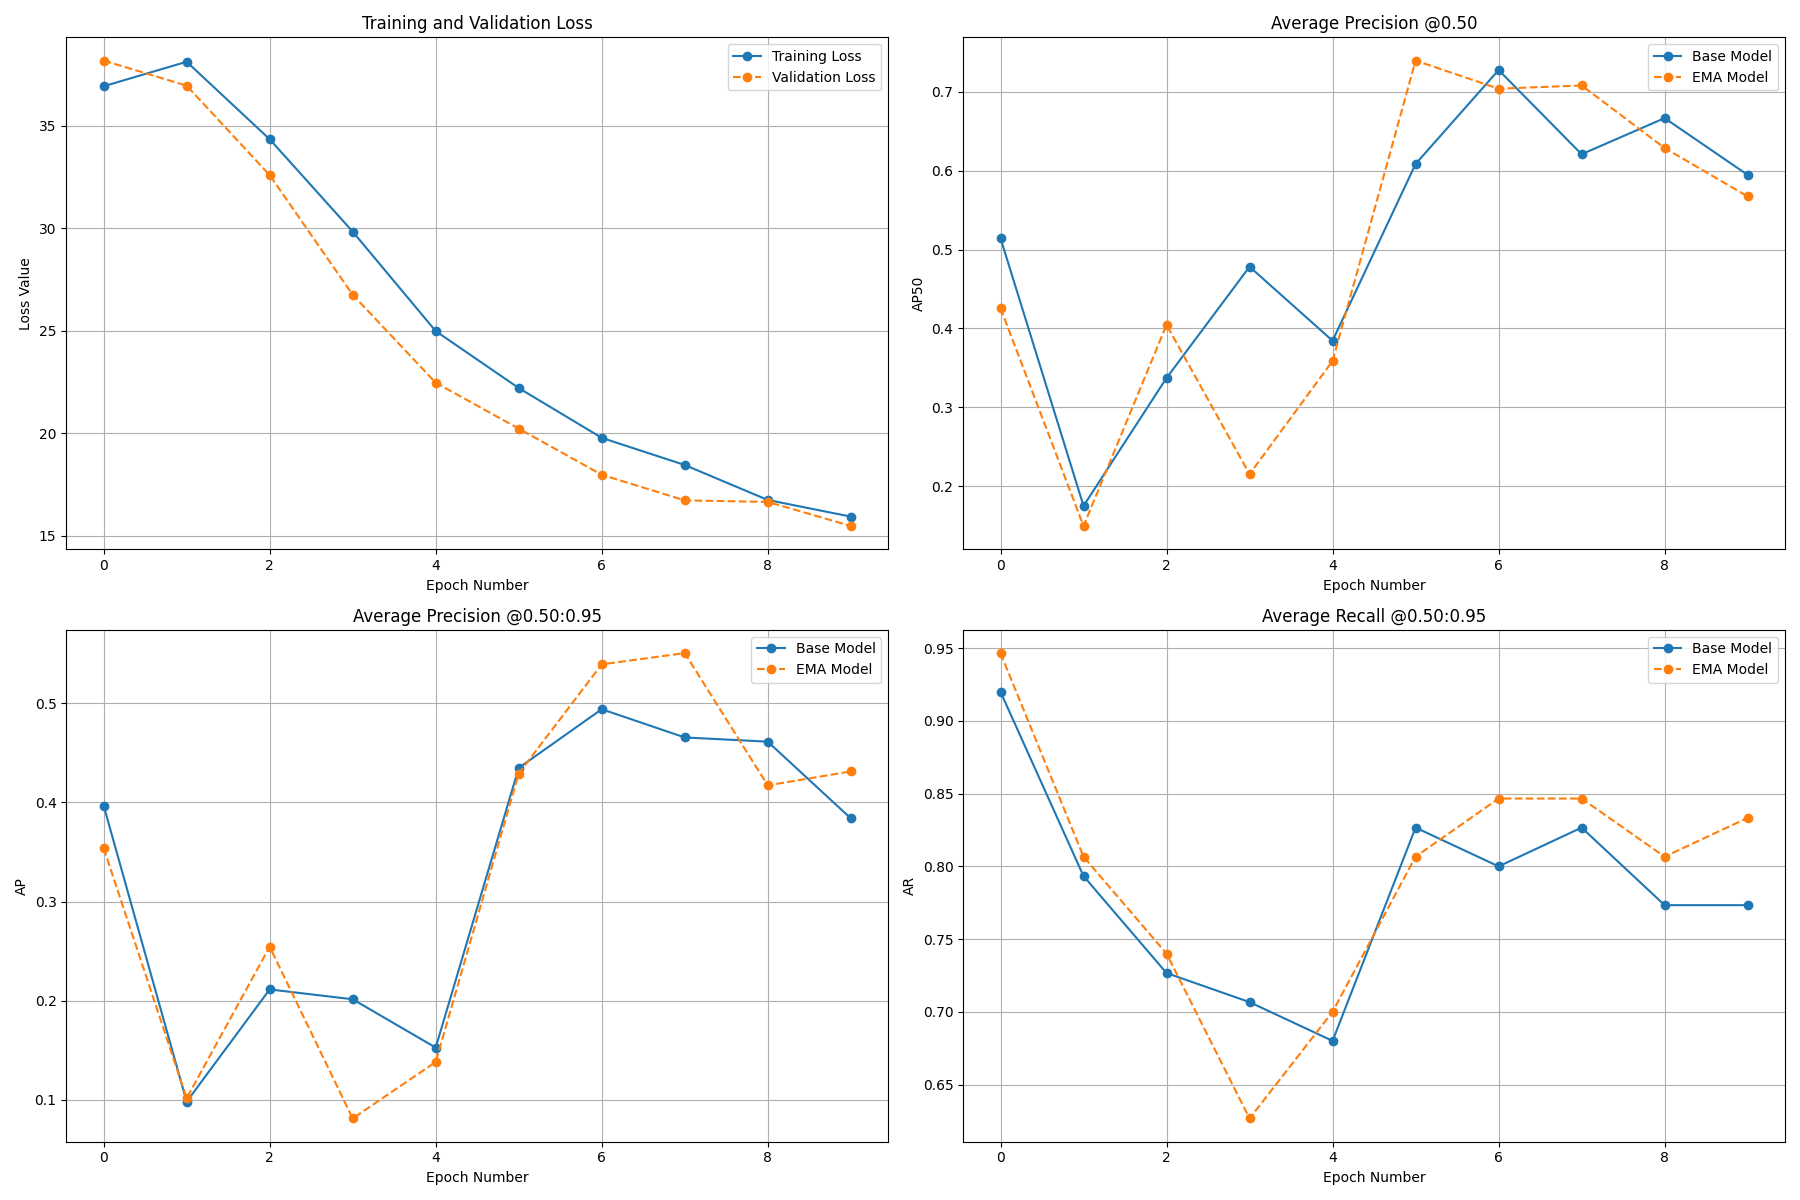

In [ ]:
from PIL import Image

Image.open("/content/output/metrics_plot.png")

The trained model is checkpoint_best_total.pth.

In [ ]:
!ls -la /content/output

total 1956476
drwxr-xr-x 3 root root      4096 Mar 29 15:02 .
drwxr-xr-x 1 root root      4096 Mar 29 14:57 ..
-rw-r--r-- 1 root root 534398511 Mar 29 15:01 checkpoint0009.pth
-rw-r--r-- 1 root root 399873726 Mar 29 15:00 checkpoint_best_ema.pth
-rw-r--r-- 1 root root 401162890 Mar 29 14:59 checkpoint_best_regular.pth
-rw------- 1 root root 133248663 Mar 29 15:01 checkpoint_best_total.pth
-rw-r--r-- 1 root root 534387619 Mar 29 15:01 checkpoint.pth
drwxr-xr-x 2 root root      4096 Mar 29 14:57 eval
-rw-r--r-- 1 root root      4412 Mar 29 15:01 events.out.tfevents.1774796221.326de40b558e.1060.0
-rw-r--r-- 1 root root    111680 Mar 29 15:01 log.txt
-rw-r--r-- 1 root root    196723 Mar 29 15:02 metrics_plot.png
-rw-r--r-- 1 root root       755 Mar 29 15:02 results.json


### Install RF-DETR to CoreML

In [ ]:
!git clone https://github.com/landchenxuan/rf-detr-to-coreml.git
%cd rf-detr-to-coreml
!pip install -q -e .

Cloning into 'rf-detr-to-coreml'...
remote: Enumerating objects: 99, done.
remote: Counting objects: 100% (99/99), done.
remote: Compressing objects: 100% (73/73), done.
remote: Total 99 (delta 38), reused 87 (delta 26), pack-reused 0 (from 0)
Receiving objects: 100% (99/99), 1.71 MiB | 21.42 MiB/s, done.
Resolving deltas: 100% (38/38), done.
/content/rf-detr-to-coreml
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 8.5 MB/s eta 0:00:00
  Building editable for rfdetr-coreml (pyproject.toml) ... done


Move the best model to the current folder and export to a Core ML model.

In [ ]:
!mv /content/output/checkpoint_best_total.pth .

In [ ]:
!rfdetr-coreml --model seg-nano --weights checkpoint_best_total.pth

scikit-learn version 1.6.1 is not supported. Minimum required version: 0.17. Maximum required version: 1.5.1. Disabling scikit-learn conversion API.
XGBoost version 3.2.0 has not been tested with coremltools. You may run into unexpected errors. XGBoost 1.4.2 is the most recent version that has been tested.
2026-03-29 15:02:41.649512: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774796561.714837    4237 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774796561.738419    4237 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774796561.768158    4237 computation_placer.cc:177] computation placer already registered. Please check linkage and 

In [ ]:
!ls -la output

total 12
drwxr-xr-x 3 root root 4096 Mar 29 15:03 .
drwxr-xr-x 7 root root 4096 Mar 29 15:03 ..
drwxr-xr-x 3 root root 4096 Mar 29 15:03 rf-detr-seg-nano-checkpoint_best_total-fp32.mlpackage


In [ ]:
%cd output

/content/rf-detr-to-coreml/output


Zip the Core ML model and download it from the File browser at the left hand. You can auto label images using the Core ML model on RectLabel.

In [ ]:
!zip -r seg-nano.zip rf-detr-seg-nano-checkpoint_best_total-fp32.mlpackage

  adding: rf-detr-seg-nano-checkpoint_best_total-fp32.mlpackage/ (stored 0%)
  adding: rf-detr-seg-nano-checkpoint_best_total-fp32.mlpackage/Manifest.json (deflated 60%)
  adding: rf-detr-seg-nano-checkpoint_best_total-fp32.mlpackage/Data/ (stored 0%)
  adding: rf-detr-seg-nano-checkpoint_best_total-fp32.mlpackage/Data/com.apple.CoreML/ (stored 0%)
  adding: rf-detr-seg-nano-checkpoint_best_total-fp32.mlpackage/Data/com.apple.CoreML/model.mlmodel (deflated 89%)
  adding: rf-detr-seg-nano-checkpoint_best_total-fp32.mlpackage/Data/com.apple.CoreML/weights/ (stored 0%)
  adding: rf-detr-seg-nano-checkpoint_best_total-fp32.mlpackage/Data/com.apple.CoreML/weights/weight.bin (deflated 7%)
